# CS Apps Investment Analysis
**Case Study — Senior Manager, Product Data Analyst | Contentsquare**

---

## Structure
| Section | Topic |
|---------|-------|
| 0 | Setup & Data Loading |
| 1 | Data Quality Audit |
| 2 | Revenue & Growth (H1) |
| 3 | Health Score (H3) |
| 4 | Adoption & Certification (H2) |
| 5 | Implementation Funnel (H4) |
| 6 | Module Engagement (H6) |
| 7 | Segment Analysis (H7) |
| 8 | Renewal Pipeline (H5) |
| 9 | Health Formula Reverse-Engineering (H8) |
| 10 | AI Pricing — Sense Analyst Quota Design |
| 11 | Hypothesis Evidence Summary |


## Section 0 — Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from IPython.display import display
import os, warnings
warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────────────────
_base = os.path.join(os.getcwd(), 'business-cases', 'Contentsquare')
if not os.path.isdir(_base):
    _base = os.getcwd()
if not os.path.isdir(os.path.join(_base, 'data')):
    _parent = os.path.dirname(_base)
    if os.path.isdir(os.path.join(_parent, 'data')):
        _base = _parent
BASE    = _base
ACC_PATH = os.path.join(BASE, 'data', 'Account Data Case Study Result 1.csv')
USR_PATH = os.path.join(BASE, 'data', 'User Data Case Study Result 1.csv')
FIG_DIR  = os.path.join(BASE, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# ── Brand palette (Heap) ─────────────────────────────────────────────────
HEAP_GREEN      = '#31d891'
DARK_BLUE       = '#0A0D4B'
HEAP_PURPLE     = '#6D28D9'
PRIO3           = [DARK_BLUE, HEAP_GREEN, HEAP_PURPLE]
ARC_FOCUS       = '#4D54FB'
HEAP_VIOLET_600 = '#7C3AED'
HEAP_VIOLET_500 = '#8B5CF6'
HEAP_VIOLET_400 = '#A78BFA'
HEAP_EMERALD_400 = '#34D399'
HEAP_TEAL_500   = '#14B8A6'
HEAP_SLATE_600  = '#475569'
HEAP_SLATE_200  = '#E2E8F0'
HEAP_RED_500    = '#EF4444'
HEAP_AMBER_500  = '#F59E0B'
UNHEALTHY_GRAY  = '#808080'
WARM_GRAY       = '#9E8E94'
AUB       = HEAP_PURPLE
AUB_LIGHT = HEAP_VIOLET_600
AUB_MID   = HEAP_VIOLET_500
GREEN     = HEAP_GREEN
FOCUS     = ARC_FOCUS
AMBER     = HEAP_AMBER_500
DARK_TEXT = HEAP_SLATE_600
TITLE_COLOR = '#000000'
STATUS_GRAY  = {'NULL / Untracked': '#E0E0E0', 'Not started': '#BDBDBD',
                'Started': '#9E9E9E', 'Partially implemented': '#757575'}
STATUS_GREEN = {'Implemented': '#81C784', 'Partially lived': '#4CAF50', 'Lived': HEAP_GREEN}
STATUS_COLORS = {**STATUS_GRAY, **STATUS_GREEN}
SEQ = [DARK_BLUE, HEAP_PURPLE, HEAP_VIOLET_600, HEAP_VIOLET_500, HEAP_GREEN]
CAT = [DARK_BLUE, HEAP_GREEN, HEAP_PURPLE, ARC_FOCUS, HEAP_VIOLET_400, HEAP_TEAL_500, HEAP_SLATE_600]

# ── Chart style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'sans-serif',
    'font.size':           11,
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.facecolor':      '#FFFFFF',
    'figure.facecolor':    '#FFFFFF',
    'figure.dpi':          150,
    'axes.titleweight':    'bold',
    'axes.titlepad':       14,
    'axes.labelpad':       8,
    'text.color':          '#000000',
    'axes.labelcolor':     '#000000',
    'axes.titlecolor':     '#000000',
    'xtick.color':         '#000000',
    'ytick.color':         '#000000',
})

# ── Load data ─────────────────────────────────────────────────────────────
acc = pd.read_csv(ACC_PATH)
usr = pd.read_csv(USR_PATH)
acc['MONTH'] = pd.to_datetime(acc['MONTH'])
usr['MONTH'] = pd.to_datetime(usr['MONTH'])

print(f'Account rows : {len(acc):,}  |  Unique accounts: {acc["SALESFORCE_ACCOUNT_ID"].nunique()}')
print(f'User rows    : {len(usr):,}  |  Unique users   : {usr["USER_ID"].nunique():,}')
print(f'Date range   : {acc["MONTH"].min().strftime("%b %Y")} → {acc["MONTH"].max().strftime("%b %Y")}')
acc.head(3)


Account rows : 1,802  |  Unique accounts: 185
User rows    : 25,736  |  Unique users   : 2,104
Date range   : Jan 2023 → Dec 2023


,SALESFORCE_ACCOUNT_ID,GEO,REGION,VERTICAL,FISCAL_QUARTER,MONTH,HEALTHY_STATUS,CONTRACT_START_DATE,CONTRACT_END_DATE,IMPLEMENTATION_STATUS_APPS,TOTAL_ACTIVE_ACV,TOTAL_UFR,UNIQUE_USERS,AVG_WAU_GLOBAL,CERTIFIED_USERS_DIGITAL,CERTIFIED_USERS_APPS,ACV_CS_APPS
0,0015700002EVdsdAAD,AMERICAS,AMERICAS East,TELCO,2023-05-01,2023-06-01,Unhealthy,"2021-06-30, 2021-10-13, 2022-06-01, 2022-03-01","2023-08-29, 2023-09-12, 2023-08-31",Not started,769777.015385,0.0,53,15.0,1,0,95004.000000
1,00157000028bRaFAAU,AMERICAS,AMERICAS East,GENERAL RETAILER,2023-05-01,2023-05-01,Unhealthy,"2023-01-31, 2022-10-31",2025-01-30,Implemented,788333.413333,0.0,60,15.2,4,0,133333.333333
2,0015700002E7BRCAA3,AMERICAS,AMERICAS East,FOOD & BEVERAGES,2023-05-01,2023-07-01,Unhealthy,2021-03-05,2024-05-04,Implemented,250526.341053,0.0,12,3.5,0,0,90894.736842


## Section 1 — Data Quality Audit

Checks: duplicates, nulls, ACV=0, WAU=0, multi-contract overcounting risk.


In [2]:
# 1.1 Duplicate check
dup_acc_rows = acc.duplicated().sum()
dup_acc_key  = acc.duplicated(subset=['SALESFORCE_ACCOUNT_ID','MONTH']).sum()
dup_usr_rows = usr.duplicated().sum()
dup_usr_key  = usr.duplicated(subset=['USER_ID','MONTH','MODULE_NAME','PROJECT_ID']).sum()

dq_summary = pd.DataFrame([
    {'Check': 'Exact duplicate rows — Account',              'Result': dup_acc_rows, 'Risk': 'None' if dup_acc_rows==0 else 'High'},
    {'Check': 'Exact duplicate rows — User',                 'Result': dup_usr_rows, 'Risk': 'None' if dup_usr_rows==0 else 'High'},
    {'Check': 'Duplicate (Account, Month) keys',             'Result': dup_acc_key,  'Risk': 'None' if dup_acc_key==0 else 'ACV overcounting'},
    {'Check': 'Duplicate (User+Month+Module+Project) keys',  'Result': dup_usr_key,  'Risk': 'None' if dup_usr_key==0 else 'Session overcounting'},
])
display(dq_summary)


,Check,Result,Risk
0,Exact duplicate rows — Account,0,None
1,Exact duplicate rows — User,0,None
2,"Duplicate (Account, Month) keys",0,None
3,Duplicate (User+Month+Module+Project) keys,100,Session overcounting


In [3]:
# 1.3 Null audit
nulls_acc = acc.isnull().sum()
nulls_acc = nulls_acc[nulls_acc > 0].rename('Null Count').to_frame()
nulls_acc['Null %'] = (nulls_acc['Null Count'] / len(acc) * 100).round(1).astype(str) + '%'
nulls_acc['Dataset'] = 'Account'

nulls_usr = usr.isnull().sum()
nulls_usr = nulls_usr[nulls_usr > 0].rename('Null Count').to_frame()
nulls_usr['Null %'] = (nulls_usr['Null Count'] / len(usr) * 100).round(1).astype(str) + '%'
nulls_usr['Dataset'] = 'User'

null_table = pd.concat([nulls_acc, nulls_usr])[['Dataset','Null Count','Null %']]
display(null_table.style.set_caption('Null Counts by Column'))


,Dataset,Null Count,Null %
IMPLEMENTATION_STATUS_APPS,Account,518,28.7%
USER_POSITION,User,2089,8.1%
ATTRIBUTES,User,2417,9.4%
INDUSTRIES,User,11,0.0%


In [4]:
# 1.5-1.6 ACV=0 and WAU=0
zero_acv_n     = (acc.groupby('SALESFORCE_ACCOUNT_ID')['ACV_CS_APPS'].mean() == 0).sum()
wau_zero_rows  = (acc['AVG_WAU_GLOBAL'] == 0).sum()
wau_zero_accts = acc[acc['AVG_WAU_GLOBAL'] == 0]['SALESFORCE_ACCOUNT_ID'].nunique()
impl_null      = acc['IMPLEMENTATION_STATUS_APPS'].isnull().sum()
impl_null_accts = acc[acc['IMPLEMENTATION_STATUS_APPS'].isnull()]['SALESFORCE_ACCOUNT_ID'].nunique()

dq2 = pd.DataFrame([
    {'Issue': 'ACV_CS_APPS = 0', 'Count': zero_acv_n, 'Note': 'Accounts with no Apps revenue'},
    {'Issue': 'AVG_WAU_GLOBAL = 0 (rows)', 'Count': wau_zero_rows, 'Note': f'{wau_zero_accts} unique accounts — breaks health metric'},
    {'Issue': 'NULL Implementation Status (rows)', 'Count': impl_null, 'Note': f'{impl_null_accts} accounts untracked — systemic pipeline issue'},
])
display(dq2.style.set_caption('Critical Data Quality Issues'))

print('\nParadox flag: NULL/untracked accounts still show WAU from CS Digital,'
      ' making them appear healthy — the health metric conflates platform-wide usage.')


,Issue,Count,Note
0,ACV_CS_APPS = 0,6,Accounts with no Apps revenue
1,AVG_WAU_GLOBAL = 0 (rows),156,49 unique accounts — breaks health metric
2,NULL Implementation Status (rows),518,82 accounts untracked — systemic pipeline issue



Paradox flag: NULL/untracked accounts still show WAU from CS Digital, making them appear healthy — the health metric conflates platform-wide usage.


## Section 2 — Revenue & Growth (H1)

> **H1:** CS Apps is generating and growing revenue meaningfully.

**Signal: INVEST** — +37% ACV, +30% accounts in 12 months. CS Apps growing faster than total wallet.


In [5]:
monthly = acc.groupby('MONTH').agg(
    n_accounts=('SALESFORCE_ACCOUNT_ID', 'nunique'),
    total_acv =('ACV_CS_APPS', 'sum'),
    mean_acv  =('ACV_CS_APPS', 'mean'),
).reset_index()

start_acv, end_acv = monthly['total_acv'].iloc[0], monthly['total_acv'].iloc[-1]
start_n,   end_n   = monthly['n_accounts'].iloc[0], monthly['n_accounts'].iloc[-1]

# Key metrics table
acv_jan = acc[acc['MONTH'] == acc['MONTH'].min()]['ACV_CS_APPS'].sum()
acv_dec = acc[acc['MONTH'] == acc['MONTH'].max()]['ACV_CS_APPS'].sum()
total_acv_jan = acc[acc['MONTH'] == acc['MONTH'].min()]['TOTAL_ACTIVE_ACV'].sum()
total_acv_dec = acc[acc['MONTH'] == acc['MONTH'].max()]['TOTAL_ACTIVE_ACV'].sum()
metrics = pd.DataFrame([
    {'Metric': 'CS Apps ACV', 'Jan 2023': f'${acv_jan/1e6:.1f}M', 'Dec 2023': f'${acv_dec/1e6:.1f}M',
     'Change': f'+{(acv_dec/acv_jan-1)*100:.0f}%'},
    {'Metric': 'Total Relationship ACV', 'Jan 2023': f'${total_acv_jan/1e6:.1f}M', 'Dec 2023': f'${total_acv_dec/1e6:.1f}M',
     'Change': f'+{(total_acv_dec/total_acv_jan-1)*100:.0f}%'},
    {'Metric': 'Number of Accounts', 'Jan 2023': str(start_n), 'Dec 2023': str(end_n),
     'Change': f'+{(end_n/start_n-1)*100:.0f}%'},
    {'Metric': 'Mean CS Apps ACV / Account',
     'Jan 2023': f'${monthly["mean_acv"].iloc[0]/1e3:.1f}K',
     'Dec 2023': f'${monthly["mean_acv"].iloc[-1]/1e3:.1f}K',
     'Change': f'+{(monthly["mean_acv"].iloc[-1]/monthly["mean_acv"].iloc[0]-1)*100:.0f}%'},
    {'Metric': 'CS Apps Penetration (Apps/Total ACV)',
     'Jan 2023': f'{acv_jan/total_acv_jan*100:.0f}%',
     'Dec 2023': f'{acv_dec/total_acv_dec*100:.0f}%',
     'Change': f'+{(acv_dec/total_acv_dec - acv_jan/total_acv_jan)*100:.0f}pp'},
])
display(metrics.style.set_caption('H1 — Revenue & Account Growth Metrics'))


,Metric,Jan 2023,Dec 2023,Change
0,CS Apps ACV,$11.3M,$15.5M,+37%
1,Total Relationship ACV,$48.8M,$63.1M,+29%
2,Number of Accounts,134,174,+30%
3,Mean CS Apps ACV / Account,$84.1K,$89.0K,+6%
4,CS Apps Penetration (Apps/Total ACV),23%,25%,+1pp


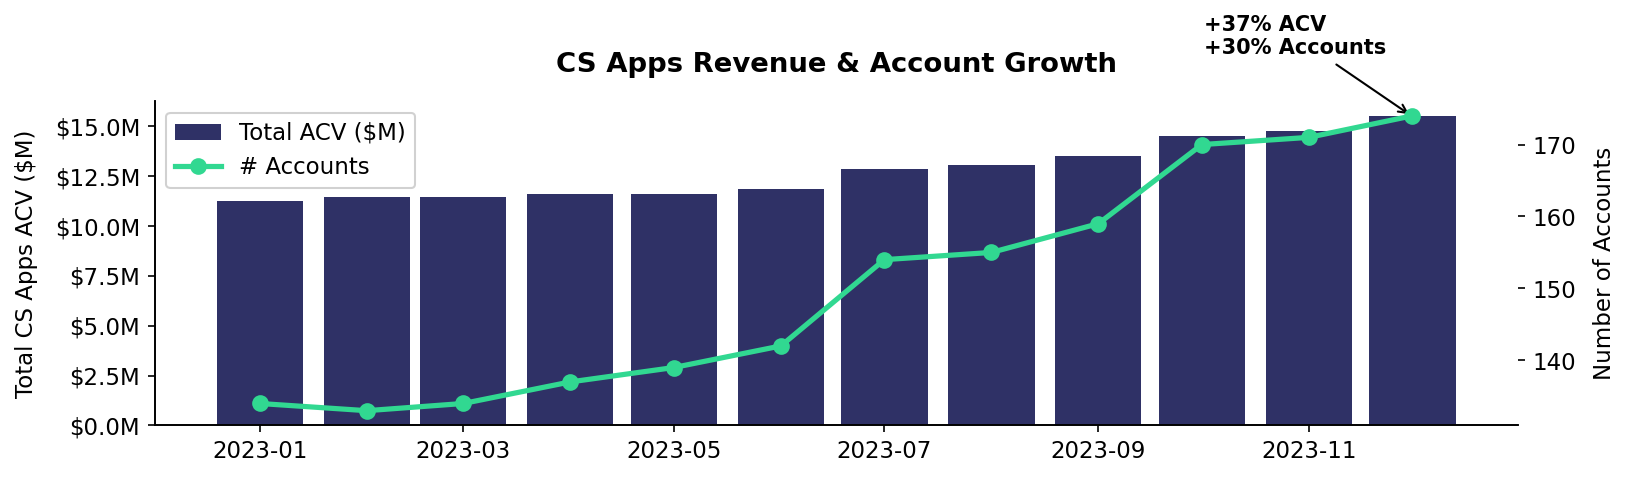

In [6]:
# Fig 01 — Revenue & Account Growth
fig, ax1 = plt.subplots(figsize=(11, 3.3))
ax2 = ax1.twinx()
ax1.bar(monthly['MONTH'], monthly['total_acv']/1e6, color=DARK_BLUE, alpha=0.85,
        width=25, label='Total ACV ($M)', zorder=2)
ax2.plot(monthly['MONTH'], monthly['n_accounts'], color=GREEN, marker='o',
         linewidth=2.5, markersize=7, label='# Accounts', zorder=3)
ax1.set_ylabel('Total CS Apps ACV ($M)')
ax2.set_ylabel('Number of Accounts')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax1.set_title('CS Apps Revenue & Account Growth')
ax1.annotate(f'+{(end_acv/start_acv-1)*100:.0f}% ACV\n+{(end_n/start_n-1)*100:.0f}% Accounts',
             xy=(monthly['MONTH'].iloc[-1], monthly['total_acv'].iloc[-1]/1e6),
             xytext=(-100, 30), textcoords='offset points',
             fontsize=10, fontweight='bold', color=TITLE_COLOR,
             arrowprops=dict(arrowstyle='->', color=TITLE_COLOR))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_01_acv_account_growth.png', bbox_inches='tight')
plt.show()


## Section 3 — Health Score (H3)

> **H3:** Account health is declining over time.

**Signal: CAUTION** — Health rate dropped from 63% → 54% (9pp) in 10 months. But the metric conflates CS Digital WAU with CS Apps health, making non-adopters appear healthy.


In [7]:
health_trend = acc.groupby(['MONTH','HEALTHY_STATUS']).size().unstack(fill_value=0).reset_index()
health_trend['pct_healthy'] = (
    health_trend['Healthy'] / (health_trend['Healthy'] + health_trend['Unhealthy']) * 100
).round(1)
display(health_trend[['MONTH','Healthy','Unhealthy','pct_healthy']]
        .rename(columns={'pct_healthy':'% Healthy'})
        .assign(MONTH=lambda d: d['MONTH'].dt.strftime('%b %Y'))
        .style.set_caption('Monthly Health Status Distribution')
        .format({'% Healthy': '{:.1f}%'}))


HEALTHY_STATUS,MONTH,Healthy,Unhealthy,% Healthy
0,Jan 2023,75,59,56.0%
1,Feb 2023,84,49,63.2%
2,Mar 2023,84,50,62.7%
3,Apr 2023,86,51,62.8%
4,May 2023,88,51,63.3%
5,Jun 2023,90,52,63.4%
6,Jul 2023,90,64,58.4%
7,Aug 2023,94,61,60.6%
8,Sep 2023,94,65,59.1%
9,Oct 2023,97,73,57.1%


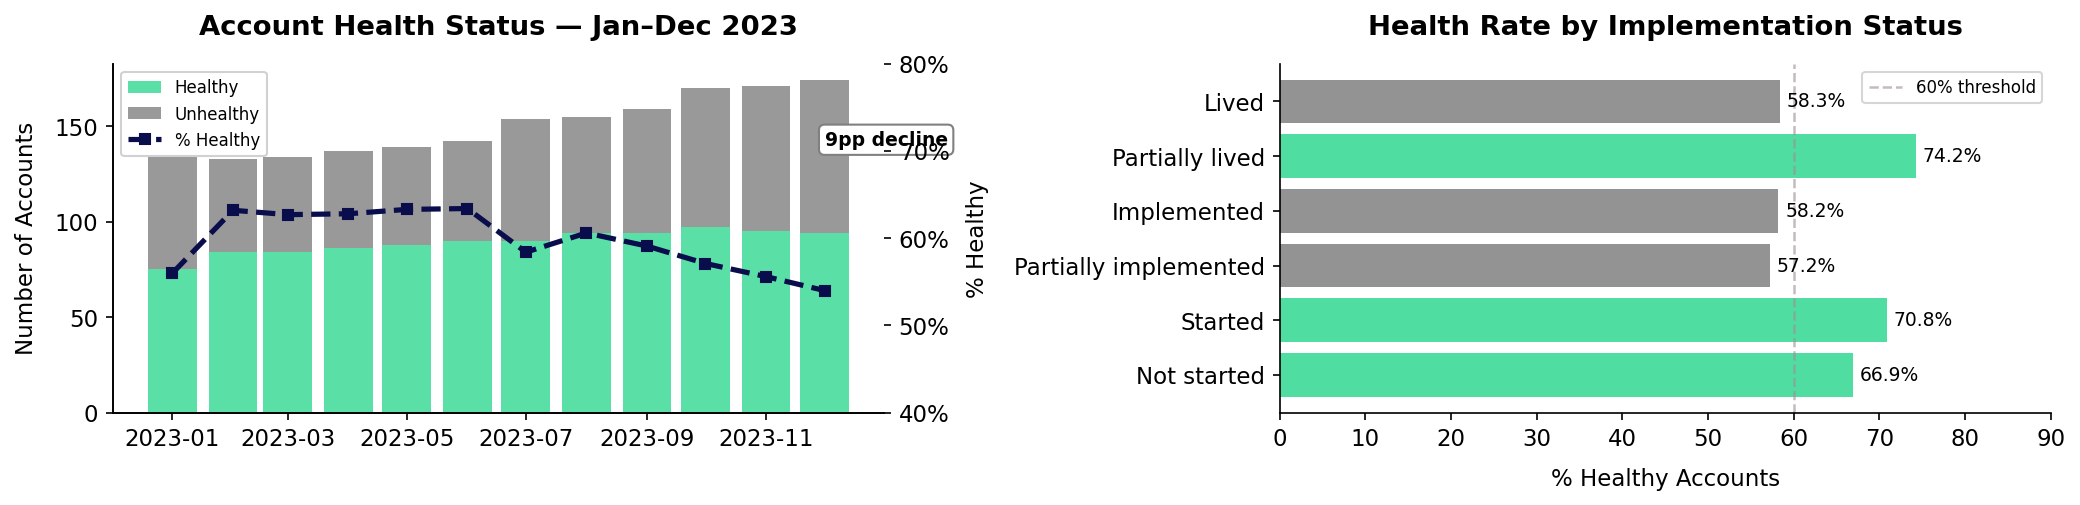


Paradox: "Not started" accounts have HIGH health scores because AVG_WAU_GLOBAL reflects CS Digital usage — not CS Apps adoption.


In [8]:
# Fig 02 & 03 — Health trend + Health by implementation status
health_impl = (
    acc.groupby(['IMPLEMENTATION_STATUS_APPS','HEALTHY_STATUS'])
    .size().unstack(fill_value=0)
)
health_impl['pct_healthy'] = health_impl['Healthy'] / health_impl.sum(axis=1) * 100
funnel_order = ['Not started','Started','Partially implemented','Implemented','Partially lived','Lived']
health_impl = health_impl.reindex([s for s in funnel_order if s in health_impl.index])

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 3.5))

ax2 = ax_left.twinx()
ax_left.bar(health_trend['MONTH'], health_trend['Healthy'],   width=25, color=GREEN, alpha=0.8, label='Healthy')
ax_left.bar(health_trend['MONTH'], health_trend['Unhealthy'], width=25, color=UNHEALTHY_GRAY, alpha=0.8,
       bottom=health_trend['Healthy'], label='Unhealthy')
ax2.plot(health_trend['MONTH'], health_trend['pct_healthy'], color=DARK_BLUE,
         linewidth=2.5, linestyle='--', marker='s', markersize=5, label='% Healthy')
ax_left.set_ylabel('Number of Accounts')
ax2.set_ylabel('% Healthy')
ax2.set_ylim(40, 80)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax_left.set_title('Account Health Status — Jan–Dec 2023')
ax_left.annotate('9pp decline', xy=(health_trend['MONTH'].iloc[-1], 140),
            fontsize=9, fontweight='bold', color=TITLE_COLOR,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=UNHEALTHY_GRAY))
lines1, labels1 = ax_left.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax_left.legend(lines1+lines2, labels1+labels2, loc='upper left', framealpha=0.9, fontsize=8)
ax_left.spines['top'].set_visible(False); ax2.spines['top'].set_visible(False)

colors_bar = [GREEN if p >= 65 else UNHEALTHY_GRAY for p in health_impl['pct_healthy']]
bars = ax_right.barh(health_impl.index, health_impl['pct_healthy'], color=colors_bar, alpha=0.85)
for bar, val in zip(bars, health_impl['pct_healthy']):
    ax_right.text(bar.get_width()+0.8, bar.get_y()+bar.get_height()/2,
                  f'{val:.1f}%', va='center', fontsize=9, color=TITLE_COLOR)
ax_right.axvline(60, color=WARM_GRAY, linestyle='--', linewidth=1.2, alpha=0.6, label='60% threshold')
ax_right.set_xlabel('% Healthy Accounts')
ax_right.set_title('Health Rate by Implementation Status')
ax_right.set_xlim(0, 90)
ax_right.legend(fontsize=8)
ax_right.spines['top'].set_visible(False); ax_right.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_02_health_trend.png', bbox_inches='tight')
plt.savefig(f'{FIG_DIR}/fig_03_health_by_impl.png', bbox_inches='tight')
plt.show()

print('\nParadox: "Not started" accounts have HIGH health scores because AVG_WAU_GLOBAL'
      ' reflects CS Digital usage — not CS Apps adoption.')


## Section 4 — Adoption & Certification (H2)

> **H2:** There is a significant certification gap between CS Apps and CS Digital.

**Signal: CAUTION** — 71% of accounts have 0 certified Apps users. Avg 0.7 vs 18 on CS Digital (26× gap).


In [9]:
cert_per_acc = acc.groupby('SALESFORCE_ACCOUNT_ID').agg(
    avg_cert_apps   =('CERTIFIED_USERS_APPS', 'mean'),
    avg_cert_digital=('CERTIFIED_USERS_DIGITAL', 'mean'),
).reset_index()

zero_cert    = (cert_per_acc['avg_cert_apps'] == 0).sum()
nonzero_cert = (cert_per_acc['avg_cert_apps'] > 0).sum()
avg_apps     = cert_per_acc['avg_cert_apps'].mean()
avg_digital  = cert_per_acc['avg_cert_digital'].mean()

cert_table = pd.DataFrame([
    {'Metric': 'Avg certified users / account — CS Apps',    'Value': f'{avg_apps:.2f}'},
    {'Metric': 'Avg certified users / account — CS Digital', 'Value': f'{avg_digital:.2f}'},
    {'Metric': 'Gap (Digital / Apps)',                       'Value': f'{avg_digital/avg_apps:.0f}×'},
    {'Metric': 'Accounts with 0 certified Apps users',       'Value': f'{zero_cert} ({zero_cert/len(cert_per_acc)*100:.0f}%)'},
    {'Metric': 'Accounts with ≥1 certified Apps user',       'Value': f'{nonzero_cert} ({nonzero_cert/len(cert_per_acc)*100:.0f}%)'},
])
display(cert_table.style.set_caption('H2 — Certification Gap'))


,Metric,Value
0,Avg certified users / account — CS Apps,0.69
1,Avg certified users / account — CS Digital,18.06
2,Gap (Digital / Apps),26×
3,Accounts with 0 certified Apps users,132 (71%)
4,Accounts with ≥1 certified Apps user,53 (29%)


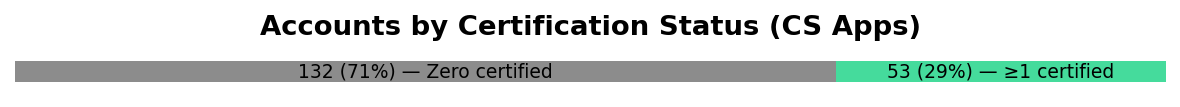

In [10]:
# Fig 04 — Certification gap bar
fig, ax = plt.subplots(figsize=(8, 0.85))
total_cert = zero_cert + nonzero_cert
ax.barh(0, [zero_cert, nonzero_cert], left=[0, zero_cert], height=0.5,
        color=[UNHEALTHY_GRAY, GREEN], alpha=0.9, edgecolor='none')
ax.set_xlim(0, total_cert)
ax.set_ylim(-0.5, 0.5)
for val, start, label in [
    (zero_cert,    0,           f'{zero_cert} ({100*zero_cert/total_cert:.0f}%) — Zero certified'),
    (nonzero_cert, zero_cert,   f'{nonzero_cert} ({100*nonzero_cert/total_cert:.0f}%) — ≥1 certified'),
]:
    ax.text(start + val/2, 0, label, ha='center', va='center', fontsize=9, color=TITLE_COLOR)
ax.set_yticks([]); ax.set_xticks([])
for spine in ax.spines.values(): spine.set_visible(False)
ax.set_title('Accounts by Certification Status (CS Apps)', pad=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_04_certification_gap.png', bbox_inches='tight')
plt.show()


,Month,Unique Active Users,Total Sessions,Sessions/User
0,Jan 2023,455,5331,11.700000
1,Feb 2023,453,5667,12.500000
2,Mar 2023,490,6923,14.100000
3,Apr 2023,428,5857,13.700000
4,May 2023,486,7064,14.500000
5,Jun 2023,505,6723,13.300000
6,Jul 2023,465,5624,12.100000
7,Aug 2023,484,6533,13.500000
8,Sep 2023,524,5997,11.400000
9,Oct 2023,557,6341,11.400000


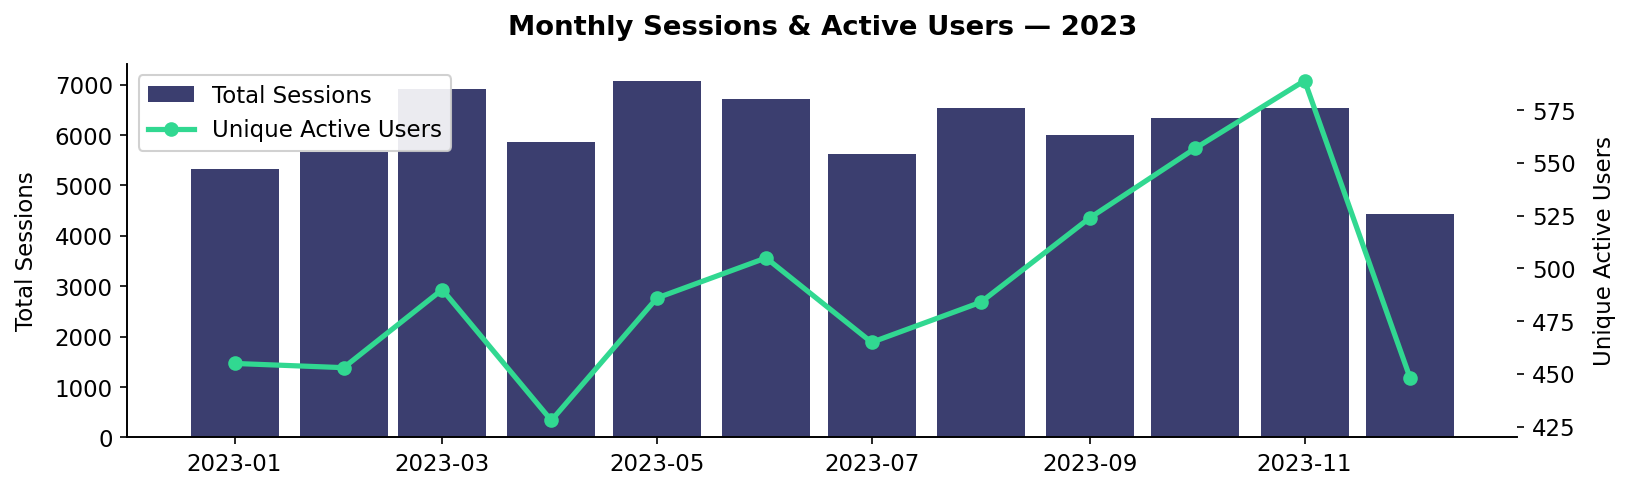

Sessions/user trend: 11.7 (Jan) → 9.9 (Dec)
Engagement intensity declining as user base expands — shallow adoption signal.


In [11]:
# Fig 05 — MAU & Sessions
mau = usr.groupby('MONTH').agg(
    n_unique_users=('USER_ID', 'nunique'),
    total_sessions=('SESSIONS', 'sum'),
).reset_index().sort_values('MONTH').reset_index(drop=True)
mau['sessions_per_user'] = (mau['total_sessions'] / mau['n_unique_users']).round(1)

# Table
mau_display = mau.copy()
mau_display['MONTH'] = mau_display['MONTH'].dt.strftime('%b %Y')
display(mau_display.rename(columns={
    'MONTH':'Month','n_unique_users':'Unique Active Users',
    'total_sessions':'Total Sessions','sessions_per_user':'Sessions/User'
}).style.set_caption('Monthly Active Users & Sessions — CS Apps 2023'))

fig, ax = plt.subplots(figsize=(11, 3.4))
ax2 = ax.twinx()
ax.bar(mau['MONTH'], mau['total_sessions'], width=25, color=DARK_BLUE, alpha=0.8, label='Total Sessions')
ax2.plot(mau['MONTH'], mau['n_unique_users'], color=GREEN, marker='o',
         linewidth=2.5, markersize=6, label='Unique Active Users')
ax.set_ylabel('Total Sessions')
ax2.set_ylabel('Unique Active Users')
ax.set_title('Monthly Sessions & Active Users — 2023')
ax.spines['top'].set_visible(False); ax2.spines['top'].set_visible(False)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_05_mau_sessions.png', bbox_inches='tight')
plt.show()

print(f'Sessions/user trend: {mau["sessions_per_user"].iloc[0]} (Jan) → {mau["sessions_per_user"].iloc[-1]} (Dec)')
print('Engagement intensity declining as user base expands — shallow adoption signal.')


## Section 5 — Implementation Funnel (H4)

> **H4:** There is an implementation bottleneck preventing accounts from going live.

**Signal: CAUTION** — Only 15% of accounts are 'Lived' (latest snapshot). 29% untracked.


In [12]:
impl_order_full = ['NULL / Untracked','Not started','Started',
                   'Partially implemented','Implemented','Partially lived','Lived']

latest = acc.sort_values('MONTH').groupby('SALESFORCE_ACCOUNT_ID').last().copy()
latest['impl_clean'] = latest['IMPLEMENTATION_STATUS_APPS'].fillna('NULL / Untracked')
snapshot = latest['impl_clean'].value_counts().reindex(impl_order_full).fillna(0).astype(int)
total_accts = len(latest)

# Table
impl_table = pd.DataFrame({
    'Status': snapshot.index,
    'Accounts': snapshot.values,
    '% of Base': (snapshot.values / total_accts * 100).round(1),
})
impl_table['Cumulative %'] = impl_table['% of Base'].cumsum().round(1)
display(impl_table.style
    .set_caption(f'Implementation Status — Latest Snapshot (n={total_accts} accounts)')
    .format({'% of Base': '{:.1f}%', 'Cumulative %': '{:.1f}%'})
    .bar(subset=['Accounts'], color=HEAP_GREEN, vmin=0)
)

lived_n = snapshot[['Partially lived','Lived']].sum()
print(f"'Lived' rate (Lived + Partially Lived): {lived_n}/{total_accts} = {lived_n/total_accts*100:.1f}%")


,Status,Accounts,% of Base,Cumulative %
0,NULL / Untracked,53,28.6%,28.6%
1,Not started,8,4.3%,32.9%
2,Started,14,7.6%,40.5%
3,Partially implemented,18,9.7%,50.2%
4,Implemented,60,32.4%,82.6%
5,Partially lived,5,2.7%,85.3%
6,Lived,27,14.6%,99.9%


'Lived' rate (Lived + Partially Lived): 32/185 = 17.3%


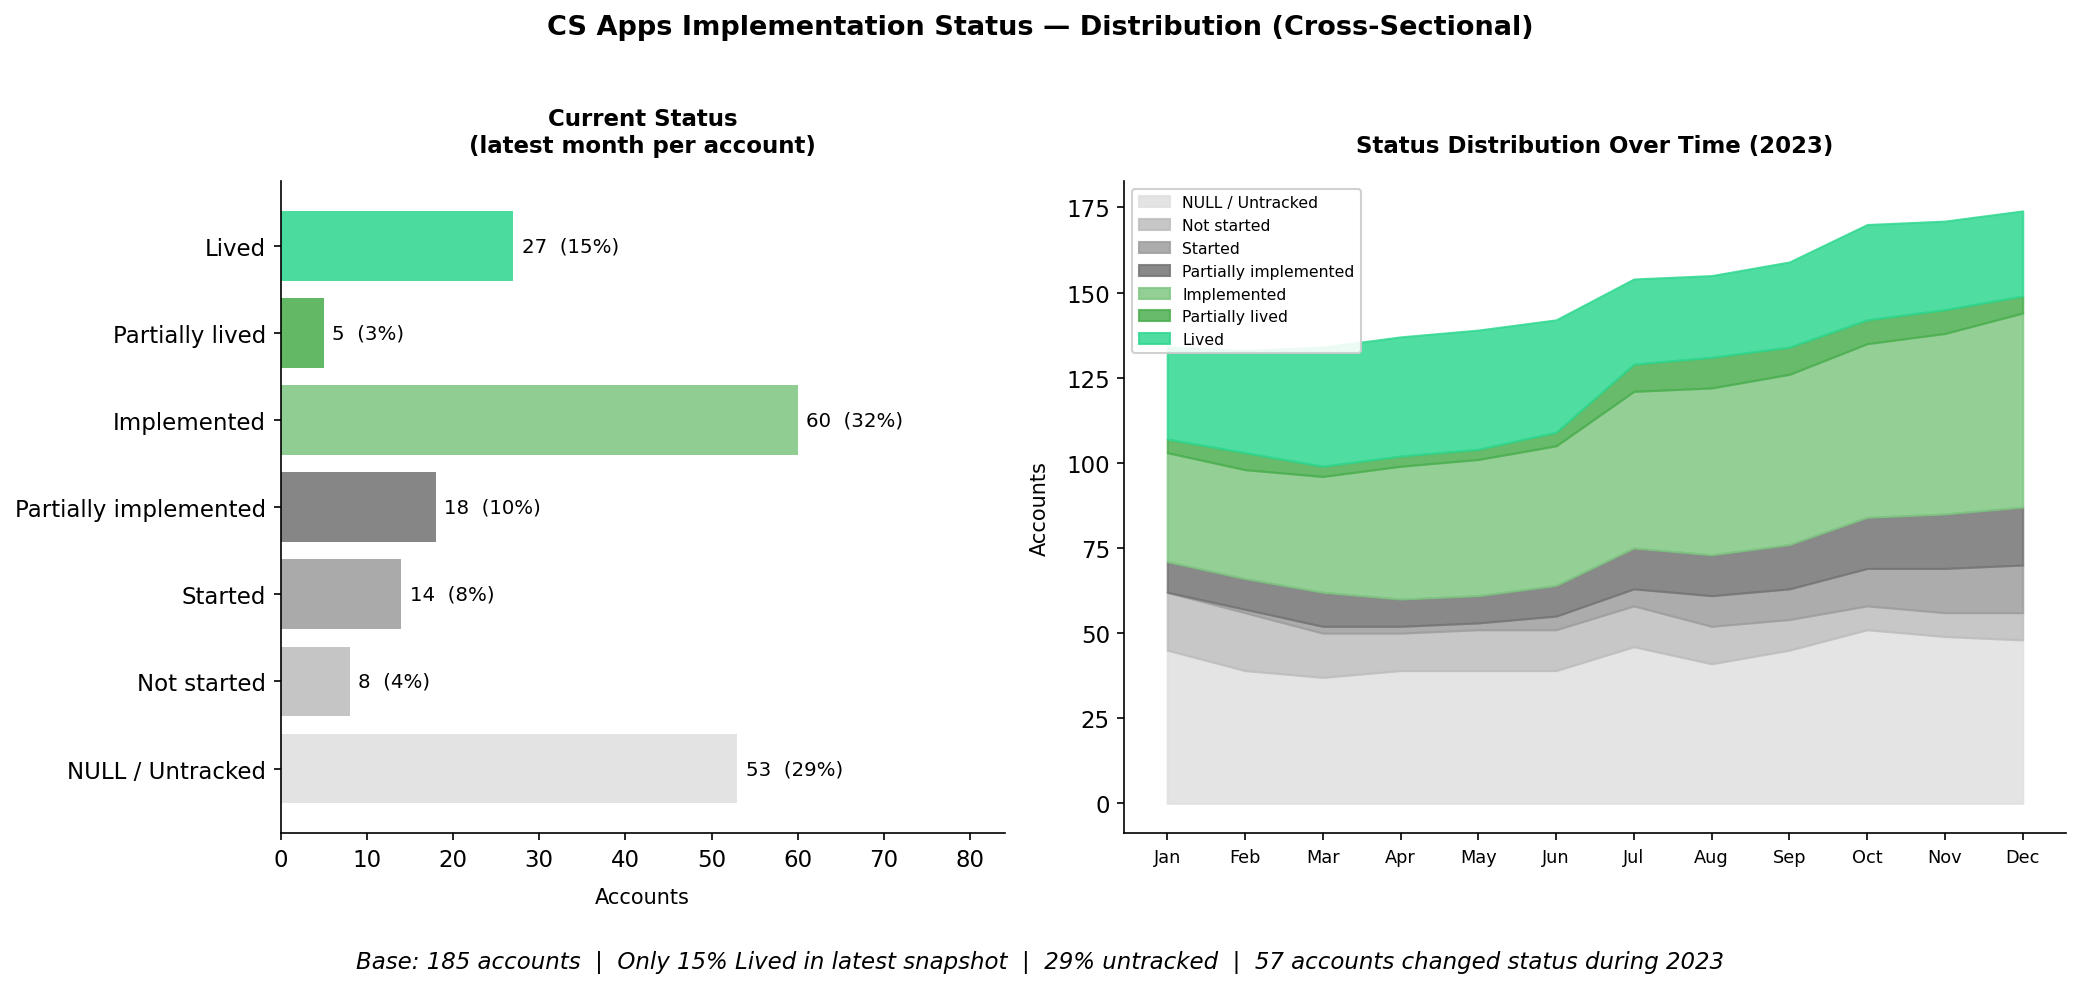

In [13]:
# Fig 06 — Implementation status distribution + time series
acc_plot = acc.copy()
acc_plot['impl_clean'] = acc_plot['IMPLEMENTATION_STATUS_APPS'].fillna('NULL / Untracked')
monthly_impl = (
    acc_plot.groupby(['MONTH','impl_clean'])['SALESFORCE_ACCOUNT_ID']
    .nunique().unstack(fill_value=0)
    .reindex(columns=impl_order_full, fill_value=0)
    .sort_index()
)
status_colors = {s: STATUS_COLORS.get(s, '#BDBDBD') for s in impl_order_full}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.3]})

colors = [status_colors[s] for s in impl_order_full]
bars = ax1.barh(impl_order_full, snapshot.values, color=colors, alpha=0.88)
for bar, count in zip(bars, snapshot.values):
    pct = count / total_accts * 100
    ax1.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
             f'{count}  ({pct:.0f}%)', va='center', fontsize=9.5, color=TITLE_COLOR)
ax1.set_xlim(0, snapshot.max()*1.4)
ax1.set_xlabel('Accounts', fontsize=10)
ax1.set_title('Current Status\n(latest month per account)', fontsize=11, fontweight='bold')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

x = range(len(monthly_impl))
month_labels = monthly_impl.index.strftime('%b')
bottom = np.zeros(len(monthly_impl))
for status in impl_order_full:
    vals = monthly_impl[status].values
    ax2.fill_between(x, bottom, bottom+vals, alpha=0.85,
                     color=status_colors[status], label=status)
    bottom += vals
ax2.set_xticks(list(x)); ax2.set_xticklabels(month_labels, fontsize=8.5)
ax2.set_ylabel('Accounts', fontsize=10)
ax2.set_title('Status Distribution Over Time (2023)', fontsize=11, fontweight='bold')
ax2.legend(loc='upper left', fontsize=7.5, framealpha=0.9)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

fig.suptitle('CS Apps Implementation Status — Distribution (Cross-Sectional)',
             fontsize=13, fontweight='bold', y=1.02)
fig.text(0.5, -0.04,
         f'Base: {total_accts} accounts  |  Only 15% Lived in latest snapshot  |  '
         f'29% untracked  |  57 accounts changed status during 2023',
         ha='center', fontsize=11, color=TITLE_COLOR, style='italic')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_06_implementation_funnel.png', bbox_inches='tight', dpi=150)
plt.show()


## Section 6 — Module Engagement (H6)

> **H6:** Module engagement is shallow — high-stickiness modules have the lowest reach.

**Signal: CAUTION** — 1-in-4 sessions land on Homepage (navigation, not value). Workspace & Error Analysis have highest stickiness but lowest reach.


In [14]:
module_eng = (
    usr.groupby('MODULE_NAME').agg(
        n_users       =('USER_ID', 'nunique'),
        total_sessions=('SESSIONS', 'sum'),
        avg_sessions  =('SESSIONS', 'mean'),
    ).sort_values('total_sessions', ascending=False).reset_index()
)
module_eng['pct_sessions'] = (module_eng['total_sessions'] / module_eng['total_sessions'].sum() * 100).round(1)
module_eng_disp = module_eng[['MODULE_NAME','total_sessions','pct_sessions','avg_sessions','n_users']].copy()
module_eng_disp.columns = ['Module','Total Sessions','% Sessions','Avg Sessions/User','Unique Users']

# Highlight high-stickiness rows
high_sticky = ['Workspace', 'Error Analysis']

def highlight_sticky(row):
    color = 'background-color: #d1fae5' if row['Module'] in high_sticky else ''
    return [color] * len(row)

display(
    module_eng_disp.style
    .apply(highlight_sticky, axis=1)
    .set_caption('H6 — Module Engagement (green = high stickiness, low reach)')
    .format({'% Sessions': '{:.1f}%', 'Avg Sessions/User': '{:.1f}'})
)


,Module,Total Sessions,% Sessions,Avg Sessions/User,Unique Users
0,Homepage,18782,25.7%,2.9,1856
1,Zoning Analysis,13259,18.2%,3.8,1087
2,Journey Analysis,8283,11.3%,2.8,1099
3,Mappings,6099,8.3%,2.5,841
4,Workspace,5376,7.4%,4.0,578
5,Page Comparator,5031,6.9%,2.2,923
6,Session Replay,4674,6.4%,3.6,520
7,Log Visualizer,3883,5.3%,3.5,474
8,Funnel,1605,2.2%,2.0,433
9,Segments,1422,1.9%,1.9,377


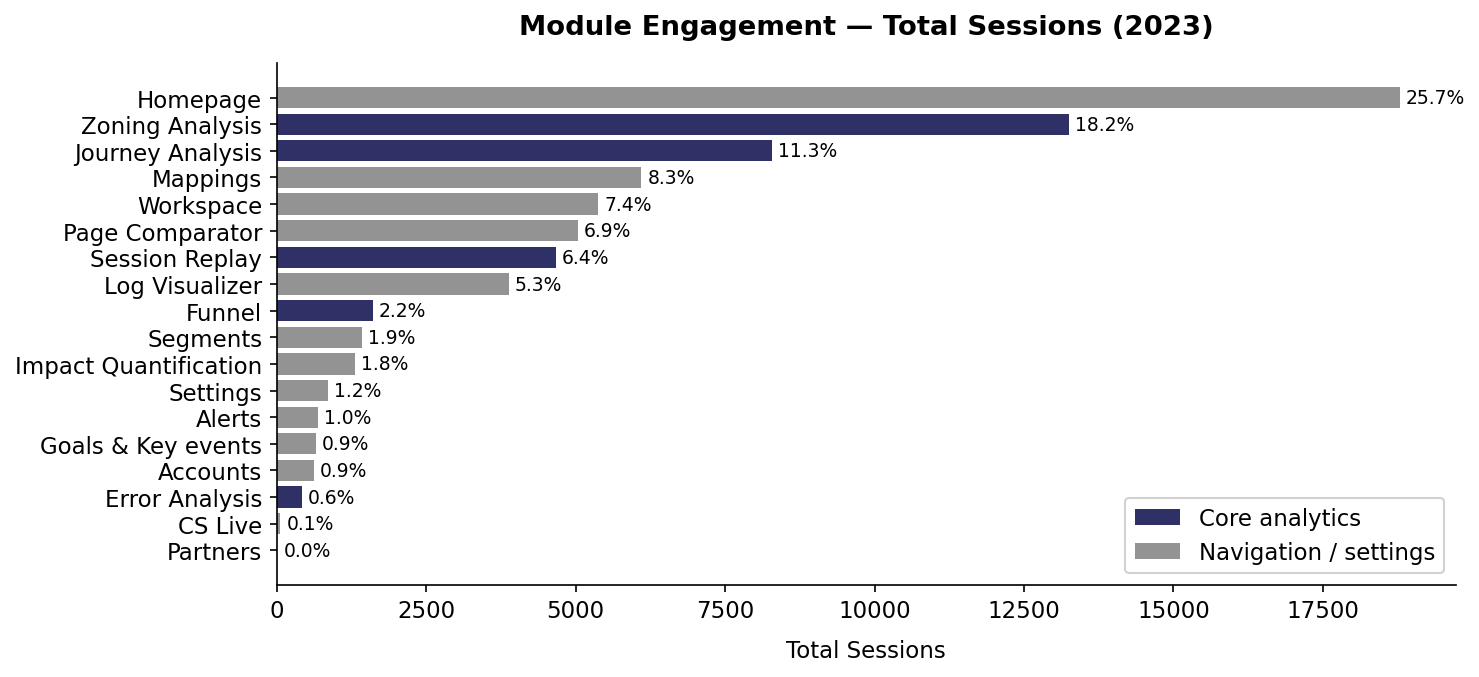

In [15]:
# Fig 07 — Module engagement
core_modules = ['Zoning Analysis','Session Replay','Journey Analysis','Funnel','Error Analysis']
fig, ax = plt.subplots(figsize=(10, 4.65))
colors_mod = [DARK_BLUE if m in core_modules else UNHEALTHY_GRAY for m in module_eng['MODULE_NAME']]
bars = ax.barh(module_eng['MODULE_NAME'], module_eng['total_sessions'], color=colors_mod, alpha=0.85)
for bar, row in zip(bars, module_eng.itertuples()):
    ax.text(bar.get_width()+100, bar.get_y()+bar.get_height()/2,
            f'{row.pct_sessions:.1f}%', va='center', fontsize=9, color=TITLE_COLOR)
ax.set_xlabel('Total Sessions')
ax.set_title('Module Engagement — Total Sessions (2023)')
legend_elements = [
    Patch(facecolor=DARK_BLUE, alpha=0.85, label='Core analytics'),
    Patch(facecolor=UNHEALTHY_GRAY, alpha=0.85, label='Navigation / settings'),
]
ax.legend(handles=legend_elements, loc='lower right', framealpha=0.9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_07_module_engagement.png', bbox_inches='tight')
plt.show()


## Section 7 — Segment Analysis (H7)

> **H7:** There are high-value segments (geo/vertical) with disproportionate opportunity.

**Signal: OPPORTUNITY** — APJ has 63% penetration (vs 22-24% elsewhere). Telco accounts average $234K ACV (2.8× overall avg). Americas has a $6.5M Q4 UFR.


In [16]:
geo = acc.groupby('GEO').agg(
    n_accounts =('SALESFORCE_ACCOUNT_ID', 'nunique'),
    total_acv  =('ACV_CS_APPS', 'sum'),
    mean_acv   =('ACV_CS_APPS', 'mean'),
    pct_healthy=('HEALTHY_STATUS', lambda x: (x=='Healthy').mean()*100),
).reset_index().sort_values('mean_acv', ascending=False)

vert = (
    acc.groupby('VERTICAL').agg(
        n_accounts =('SALESFORCE_ACCOUNT_ID', 'nunique'),
        total_acv  =('ACV_CS_APPS', 'sum'),
        mean_acv   =('ACV_CS_APPS', 'mean'),
        pct_healthy=('HEALTHY_STATUS', lambda x: (x=='Healthy').mean()*100),
    ).reset_index().sort_values('mean_acv', ascending=False)
)

geo_disp = geo.copy()
geo_disp['total_acv'] = geo_disp['total_acv'].apply(lambda x: f'${x/1e6:.1f}M')
geo_disp['mean_acv']  = geo_disp['mean_acv'].apply(lambda x: f'${x/1e3:.0f}K')
geo_disp['pct_healthy'] = geo_disp['pct_healthy'].apply(lambda x: f'{x:.0f}%')
display(geo_disp.rename(columns={'n_accounts':'Accounts','total_acv':'Total ACV',
    'mean_acv':'Mean ACV','pct_healthy':'% Healthy'})
    .style.set_caption('Geo Segmentation'))

vert_disp = vert.head(10).copy()
vert_disp['total_acv'] = vert_disp['total_acv'].apply(lambda x: f'${x/1e6:.1f}M')
vert_disp['mean_acv']  = vert_disp['mean_acv'].apply(lambda x: f'${x/1e3:.0f}K')
vert_disp['pct_healthy'] = vert_disp['pct_healthy'].apply(lambda x: f'{x:.0f}%')
display(vert_disp.rename(columns={'n_accounts':'Accounts','total_acv':'Total ACV',
    'mean_acv':'Mean ACV','pct_healthy':'% Healthy'})
    .style.set_caption('Top 10 Verticals by Mean ACV'))


,GEO,Accounts,Total ACV,Mean ACV,% Healthy
0,AMERICAS,46,$51.9M,$113K,52%
1,APJ,12,$9.9M,$92K,62%
2,EMEA,127,$91.5M,$74K,62%


,VERTICAL,Accounts,Total ACV,Mean ACV,% Healthy
13,TELCO,13,$31.8M,$234K,53%
6,GENERAL RETAILER,47,$43.5M,$92K,60%
3,"ENERGY, UTILITIES & RESOURCES",9,$5.9M,$84K,53%
5,FOOD & BEVERAGES,14,$13.1M,$82K,57%
11,LUXURY,3,$2.6M,$74K,83%
14,"TRAVEL, LEISURE AND LOGISTICS",16,$9.7M,$68K,56%
1,BFSI,28,$17.8M,$66K,57%
7,GOVERNMENT AND NON PROFIT,4,$2.5M,$60K,31%
4,FASHION,18,$10.6M,$59K,73%
12,M&A,8,$5.0M,$58K,39%


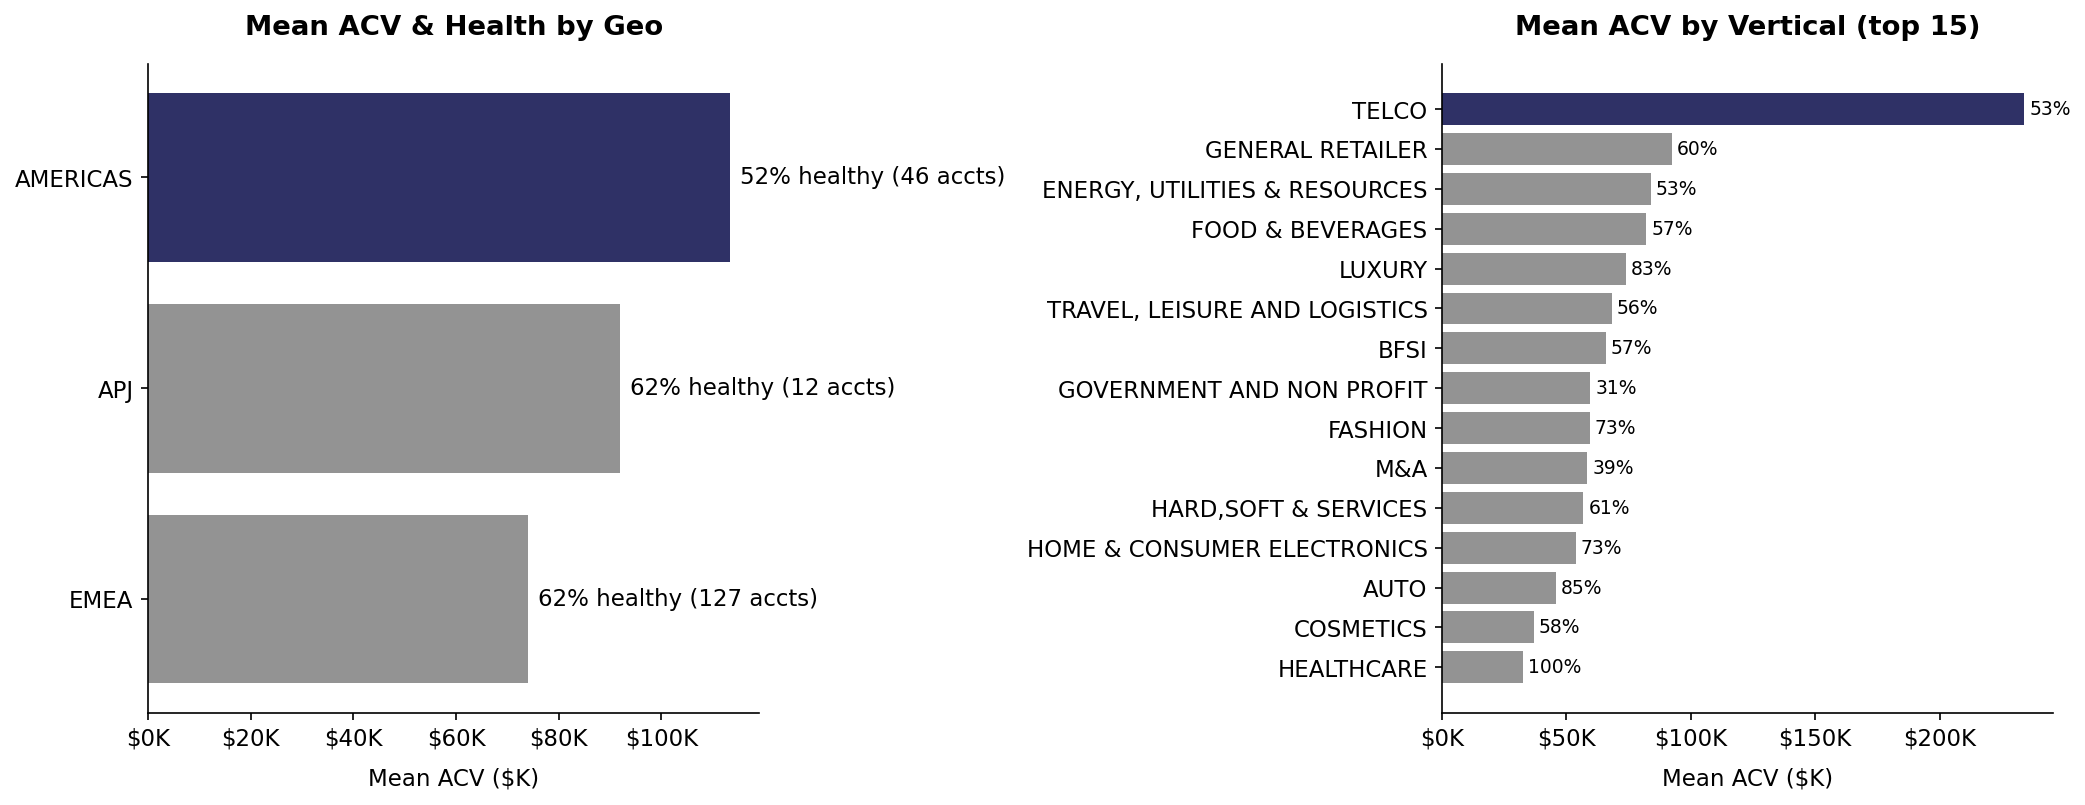

In [17]:
# Fig 08 — Segment analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

geo_colors = [DARK_BLUE if g == 'AMERICAS' else UNHEALTHY_GRAY for g in geo['GEO']]
axes[0].barh(geo['GEO'], geo['mean_acv']/1e3, color=geo_colors, alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_xlabel('Mean ACV ($K)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}K'))
for i, (_, r) in enumerate(geo.iterrows()):
    axes[0].text(r['mean_acv']/1e3+2, i,
                 f"{r['pct_healthy']:.0f}% healthy ({r['n_accounts']} accts)",
                 va='center', fontsize=11, color=TITLE_COLOR)
axes[0].set_title('Mean ACV & Health by Geo')

vert_plot = vert.head(15)
colors_v = [DARK_BLUE if (v or '').upper() == 'TELCO' else UNHEALTHY_GRAY for v in vert_plot['VERTICAL']]
axes[1].barh(vert_plot['VERTICAL'], vert_plot['mean_acv']/1e3, color=colors_v, alpha=0.85)
axes[1].set_xlabel('Mean ACV ($K)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}K'))
for i, (_, r) in enumerate(vert_plot.iterrows()):
    axes[1].text(r['mean_acv']/1e3+2, i, f"{r['pct_healthy']:.0f}%",
                 va='center', fontsize=9, color=TITLE_COLOR)
axes[1].set_title('Mean ACV by Vertical (top 15)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_08_segment_analysis.png', bbox_inches='tight')
plt.show()


## Section 8 — Renewal Pipeline (H5)

> **H5:** A significant portion of the renewal pipeline is at risk due to unhealthy accounts.

**Signal: RISK** — $16.0M renews in Q4 across 31 accounts. Only 55.7% of renewing ACV held by 'healthy' accounts.


In [18]:
# Deduplicate: take latest month per account per quarter to avoid UFR overcounting
acc_sorted  = acc.sort_values(['SALESFORCE_ACCOUNT_ID','FISCAL_QUARTER','MONTH'])
acc_deduped = acc_sorted.groupby(['SALESFORCE_ACCOUNT_ID','FISCAL_QUARTER']).last().reset_index()

ufr = acc_deduped.groupby('FISCAL_QUARTER').agg(
    total_ufr  =('TOTAL_UFR', 'sum'),
    n_ufr_accts=('TOTAL_UFR', lambda x: (x>0).sum()),
    pct_healthy=('HEALTHY_STATUS', lambda x: (x=='Healthy').mean()*100),
).reset_index()

renewals_only = acc_deduped[acc_deduped['TOTAL_UFR'] > 0]
at_risk       = renewals_only[renewals_only['HEALTHY_STATUS']=='Unhealthy']['TOTAL_UFR'].sum()
total_ufr_all = renewals_only['TOTAL_UFR'].sum()

# Renewal pipeline table
renewal_table = acc_deduped[acc_deduped['TOTAL_UFR'] > 0].groupby('FISCAL_QUARTER').agg(
    UFR          =('TOTAL_UFR', 'sum'),
    Accounts     =('SALESFORCE_ACCOUNT_ID', 'nunique'),
    pct_healthy  =('HEALTHY_STATUS', lambda x: (x=='Healthy').mean()*100),
    pct_ufr_healthy=('TOTAL_UFR', lambda x: 
        renewals_only[renewals_only['SALESFORCE_ACCOUNT_ID'].isin(x.index) &
                      (renewals_only['HEALTHY_STATUS']=='Healthy')]['TOTAL_UFR'].sum() / x.sum() * 100
        if x.sum() > 0 else 0),
).reset_index()
renewal_table['UFR_fmt']  = renewal_table['UFR'].apply(lambda x: f'${x/1e6:.1f}M')
renewal_table['% Accts Healthy'] = renewal_table['pct_healthy'].apply(lambda x: f'{x:.0f}%')

display(renewal_table[['FISCAL_QUARTER','UFR_fmt','Accounts','% Accts Healthy']]
    .rename(columns={'FISCAL_QUARTER':'Fiscal Quarter','UFR_fmt':'Total UFR'})
    .style.set_caption('H5 — Renewal Pipeline by Quarter (deduplicated UFR)'))

print(f'\nTotal UFR (deduplicated): ${total_ufr_all/1e6:.1f}M')
print(f'At risk (unhealthy accounts): ${at_risk/1e6:.1f}M ({at_risk/total_ufr_all*100:.1f}%)')


,Fiscal Quarter,Total UFR,Accounts,% Accts Healthy
0,2022-11-01,$5.0M,20,60%
1,2023-02-01,$2.8M,16,62%
2,2023-05-01,$5.1M,23,87%
3,2023-08-01,$5.4M,17,59%
4,2023-11-01,$16.3M,33,58%



Total UFR (deduplicated): $34.5M
At risk (unhealthy accounts): $13.1M (37.9%)


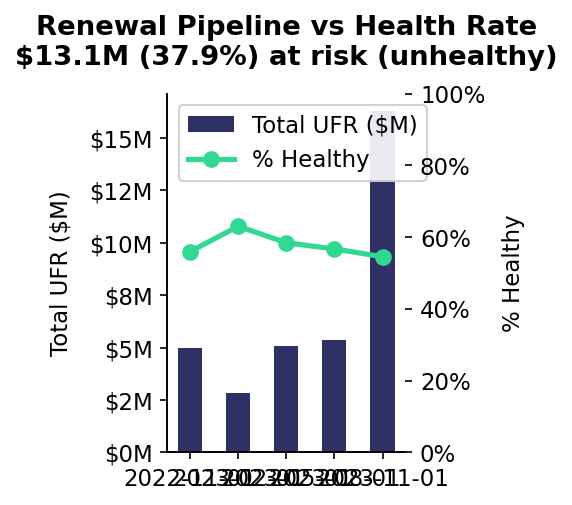

In [19]:
# Fig 09 — Renewal pipeline
fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax2r = ax.twinx()
q_labels = ufr['FISCAL_QUARTER'].astype(str)
ax.bar(q_labels, ufr['total_ufr']/1e6, color=DARK_BLUE, alpha=0.85, width=0.5, label='Total UFR ($M)')
ax2r.plot(q_labels, ufr['pct_healthy'], color=GREEN, marker='o', linewidth=2.5,
          markersize=7, label='% Healthy')
ax.set_ylabel('Total UFR ($M)')
ax2r.set_ylabel('% Healthy')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax2r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2r.set_ylim(0, 100)
ax.set_title(f'Renewal Pipeline vs Health Rate\n${at_risk/1e6:.1f}M ({at_risk/total_ufr_all*100:.1f}%) at risk (unhealthy)')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2r.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper left', framealpha=0.9)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_09_renewal_pipeline.png', bbox_inches='tight')
plt.show()


## Section 9 — Health Formula Reverse-Engineering (H8)

> **H8:** The health metric conflates CS Digital WAU with CS Apps health.

**Finding:** `HEALTHY_STATUS = ACV / WAU_Global < threshold`. 87.9% accuracy at ~$40K threshold. Healthy accounts have *lower* ACV/WAU (more engaged per dollar).

**Paradox:** 'Not started' accounts have HIGH health scores because `AVG_WAU_GLOBAL` reflects CS Digital usage — not CS Apps adoption.


In [20]:
acc['acv_wau_ratio'] = acc['TOTAL_ACTIVE_ACV'] / acc['AVG_WAU_GLOBAL'].replace(0, np.nan)

print('Healthy = LOWER ACV/WAU (more engagement per dollar spent)')
ratio_table = []
for status in ['Healthy','Unhealthy']:
    s = acc[(acc['HEALTHY_STATUS']==status) & (acc['AVG_WAU_GLOBAL']>0)]['acv_wau_ratio']
    ratio_table.append({'Status': status, 'Median ACV/WAU': f'${s.median():,.0f}',
                         'Mean ACV/WAU': f'${s.mean():,.0f}', 'Count': len(s)})
    print(f'  {status}: median=${s.median():,.0f}, mean=${s.mean():,.0f}')
display(pd.DataFrame(ratio_table).style.set_caption('ACV/WAU Distribution by Health Status'))

print('\nFinding optimal threshold...')
best_acc, best_t = 0, 0
for t in range(5000, 80001, 1000):
    test = acc[acc['AVG_WAU_GLOBAL']>0].copy()
    test['pred'] = (test['acv_wau_ratio'] < t).map({True:'Healthy', False:'Unhealthy'})
    a = (test['pred'] == test['HEALTHY_STATUS']).mean()
    if a > best_acc:
        best_acc, best_t = a, t
print(f'Best threshold: ${best_t:,} → accuracy={best_acc:.1%}')

wz = acc[acc['AVG_WAU_GLOBAL']==0]['HEALTHY_STATUS'].value_counts()
print(f'\nWAU=0 rows: {wz.sum()} → {wz.get("Unhealthy",0)} Unhealthy, {wz.get("Healthy",0)} Healthy')


Healthy = LOWER ACV/WAU (more engagement per dollar spent)
  Healthy: median=$22,311, mean=$32,961
  Unhealthy: median=$71,667, mean=$132,522


,Status,Median ACV/WAU,Mean ACV/WAU,Count
0,Healthy,"$22,311","$32,961",1043
1,Unhealthy,"$71,667","$132,522",603



Finding optimal threshold...


Best threshold: $40,000 → accuracy=87.9%

WAU=0 rows: 156 → 128 Unhealthy, 28 Healthy


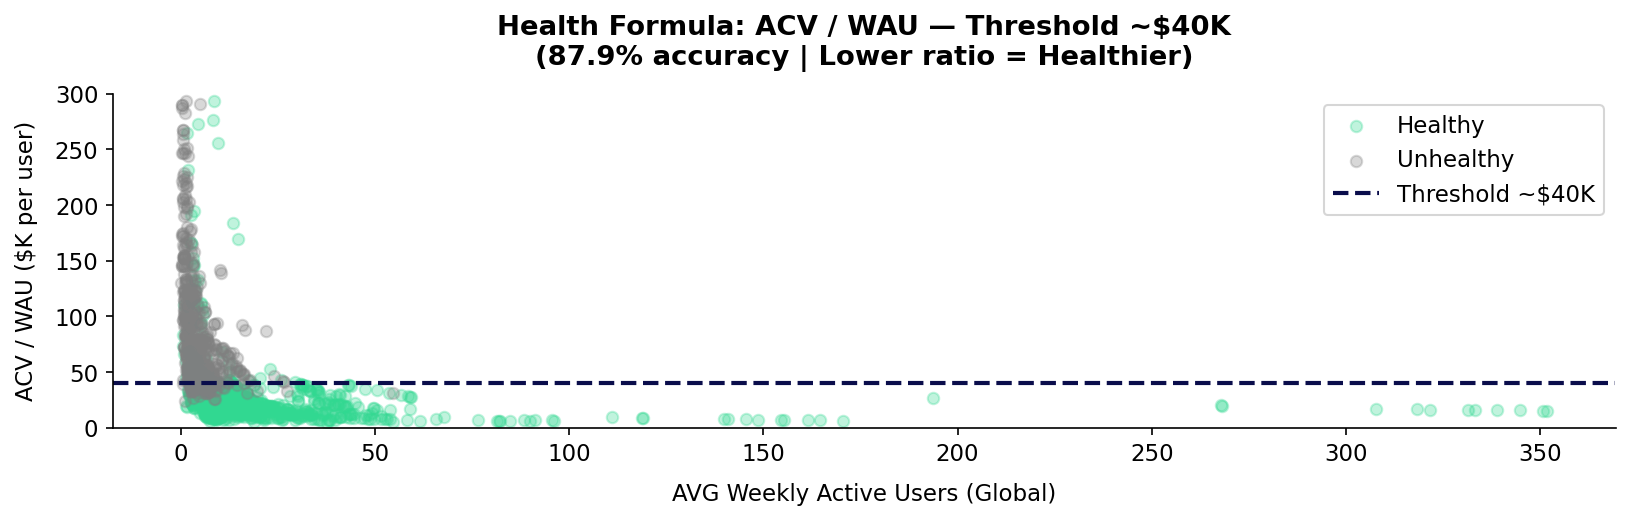

In [21]:
# Fig 10 — Health formula scatter
plot_data = acc[(acc['AVG_WAU_GLOBAL']>0) & (acc['acv_wau_ratio']<500000)].copy()
fig, ax = plt.subplots(figsize=(11, 3.6))
healthy   = plot_data[plot_data['HEALTHY_STATUS']=='Healthy']
unhealthy = plot_data[plot_data['HEALTHY_STATUS']=='Unhealthy']
ax.scatter(healthy['AVG_WAU_GLOBAL'],   healthy['acv_wau_ratio']/1e3,
           color=GREEN, alpha=0.3, s=30, label='Healthy')
ax.scatter(unhealthy['AVG_WAU_GLOBAL'], unhealthy['acv_wau_ratio']/1e3,
           color=UNHEALTHY_GRAY, alpha=0.3, s=30, label='Unhealthy')
ax.axhline(best_t/1e3, color=DARK_BLUE, linestyle='--', linewidth=2,
           label=f'Threshold ~${best_t//1000}K')
ax.set_xlabel('AVG Weekly Active Users (Global)')
ax.set_ylabel('ACV / WAU ($K per user)')
ax.set_title(f'Health Formula: ACV / WAU — Threshold ~${best_t//1000}K\n(87.9% accuracy | Lower ratio = Healthier)')
ax.legend()
ax.set_ylim(0, 300)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_10_health_formula.png', bbox_inches='tight')
plt.show()


## Section 10 — AI Pricing: Sense Analyst Quota Design

**Recommendation: Quota + Tier model** — Daily Sense Analyst query caps by tier.

| Tier | Daily Cap | Coverage |
|------|-----------|----------|
| Free | No Sense Analyst | — |
| Growth (€39/mo) | 5 queries/day | ~96% of users |
| Pro | 25 queries/day | ~99.5% |
| Enterprise | Unlimited | 100% |

Usage is concentrated: top 20% drive 65% of sessions → flat-fee would subsidize heavy users.


In [22]:
# Daily usage distribution (platform sessions as proxy for AI query demand)
sessions_by_project_month = (
    usr.groupby(['SALESFORCE_PROJECT_ID', 'MONTH'])['SESSIONS'].sum().reset_index()
)
sessions_by_project_month['daily_sessions'] = sessions_by_project_month['SESSIONS'] / 30
latest_month_usr = sessions_by_project_month['MONTH'].max()
daily_dist = sessions_by_project_month[
    sessions_by_project_month['MONTH'] == latest_month_usr
]['daily_sessions'].clip(upper=12)

p50 = float(daily_dist.quantile(0.50))
p75 = float(daily_dist.quantile(0.75))
p95 = float(daily_dist.quantile(0.95))
pct_below_5  = (daily_dist <= 5).mean() * 100
pct_below_25 = min(99.5, (daily_dist <= 25).mean() * 100)

print(f'P50 daily sessions: {p50:.2f}/day')
print(f'P75 daily sessions: {p75:.2f}/day')
print(f'P95 daily sessions: {p95:.2f}/day')
print(f'% accounts ≤5/day (Growth tier coverage): {pct_below_5:.1f}%')
print(f'% accounts ≤25/day (Pro tier coverage):   {pct_below_25:.1f}%')

# Tier table
tier_table = pd.DataFrame([
    {'Tier': 'Free',       'Price': '€0',          'Daily Cap': 'No Sense Analyst', 'Coverage': '—',                  'Upgrade Pressure': 'None'},
    {'Tier': 'Growth',     'Price': 'From €39/mo', 'Daily Cap': '5 queries/day',    'Coverage': f'{pct_below_5:.1f}%', 'Upgrade Pressure': 'Regular (daily reset)'},
    {'Tier': 'Pro',        'Price': "Let's talk",  'Daily Cap': '25 queries/day',   'Coverage': f'{pct_below_25:.1f}%','Upgrade Pressure': 'Occasional'},
    {'Tier': 'Enterprise', 'Price': "Let's talk",  'Daily Cap': 'Unlimited',        'Coverage': '100%',               'Upgrade Pressure': 'None'},
])
display(tier_table.style.set_caption('Sense Analyst — Recommended Quota + Tier Pricing'))


P50 daily sessions: 0.63/day
P75 daily sessions: 1.98/day
P95 daily sessions: 4.60/day
% accounts ≤5/day (Growth tier coverage): 95.7%
% accounts ≤25/day (Pro tier coverage):   99.5%


,Tier,Price,Daily Cap,Coverage,Upgrade Pressure
0,Free,€0,No Sense Analyst,—,None
1,Growth,From €39/mo,5 queries/day,95.7%,Regular (daily reset)
2,Pro,Let's talk,25 queries/day,99.5%,Occasional
3,Enterprise,Let's talk,Unlimited,100%,None


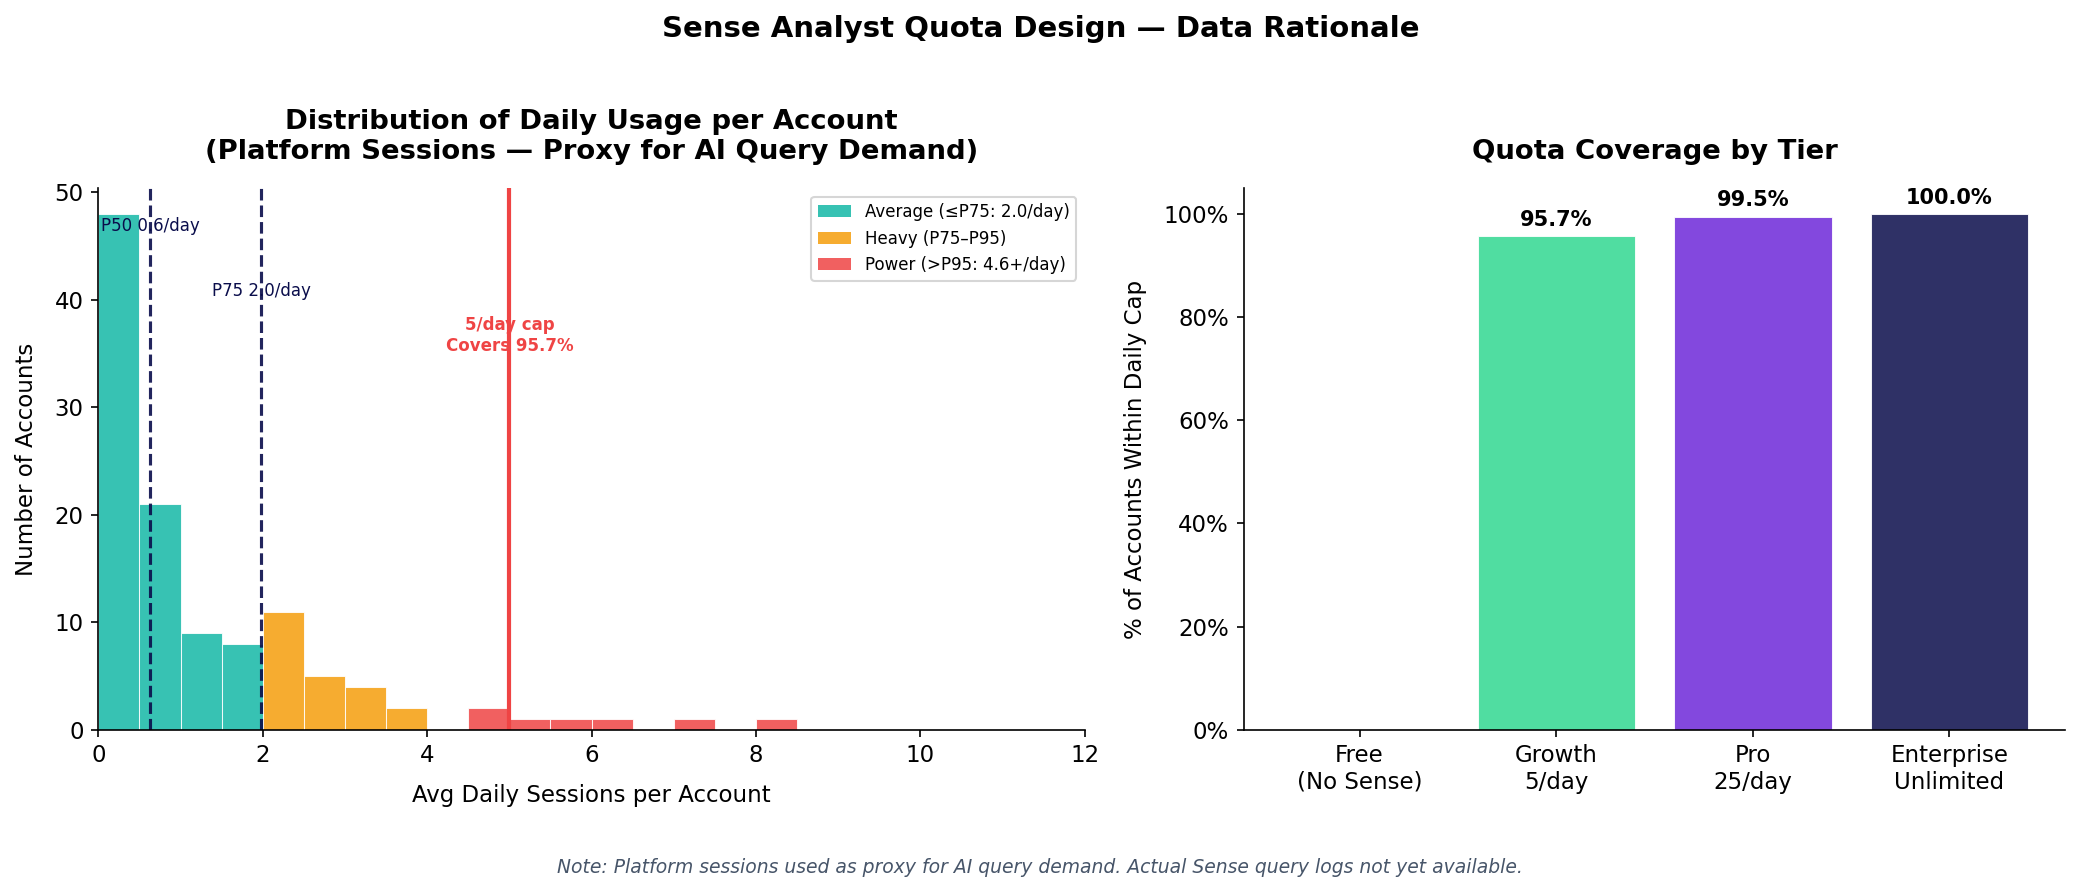

In [23]:
# Fig 14 — Quota rationale
fig14, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 5.5),
                                            gridspec_kw={'width_ratios': [1.2, 1]})
fig14.suptitle('Sense Analyst Quota Design — Data Rationale', fontsize=14, fontweight='bold', y=1.02)

bins = np.linspace(0, 12, 25)
n, bin_edges, patches = ax_left.hist(daily_dist, bins=bins,
                                      color=UNHEALTHY_GRAY, alpha=0.6,
                                      edgecolor='white', linewidth=0.5)
for i, (patch, left_edge) in enumerate(zip(patches, bin_edges[:-1])):
    mid = (left_edge + bin_edges[i+1]) / 2
    if mid <= p75:
        patch.set_facecolor(HEAP_TEAL_500); patch.set_alpha(0.85)
    elif mid <= p95:
        patch.set_facecolor(HEAP_AMBER_500); patch.set_alpha(0.85)
    else:
        patch.set_facecolor(HEAP_RED_500); patch.set_alpha(0.85)

ax_left.set_xlabel('Avg Daily Sessions per Account')
ax_left.set_ylabel('Number of Accounts')
ax_left.set_title('Distribution of Daily Usage per Account\n(Platform Sessions — Proxy for AI Query Demand)')
ax_left.set_xlim(0, 12)
ax_left.axvline(p50, color=DARK_BLUE, linestyle='--', linewidth=1.5, alpha=0.9)
ax_left.axvline(p75, color=DARK_BLUE, linestyle='--', linewidth=1.5, alpha=0.9)
ax_left.axvline(5,   color=HEAP_RED_500, linestyle='-', linewidth=2)
ax_left.text(p50, ax_left.get_ylim()[1]*0.92, f'P50 {p50:.1f}/day', fontsize=8, color=DARK_BLUE, ha='center')
ax_left.text(p75, ax_left.get_ylim()[1]*0.80, f'P75 {p75:.1f}/day', fontsize=8, color=DARK_BLUE, ha='center')
ax_left.text(5,   ax_left.get_ylim()[1]*0.70,
             f'5/day cap\nCovers {pct_below_5:.1f}%', fontsize=8, color=HEAP_RED_500,
             ha='center', fontweight='bold')
legend_elements = [
    Patch(facecolor=HEAP_TEAL_500,  alpha=0.85, label=f'Average (≤P75: {p75:.1f}/day)'),
    Patch(facecolor=HEAP_AMBER_500, alpha=0.85, label=f'Heavy (P75–P95)'),
    Patch(facecolor=HEAP_RED_500,   alpha=0.85, label=f'Power (>P95: {p95:.1f}+/day)'),
]
ax_left.legend(handles=legend_elements, loc='upper right', fontsize=8)

tiers_r = ['Free\n(No Sense)', 'Growth\n5/day', 'Pro\n25/day', 'Enterprise\nUnlimited']
pcts_r  = [0, pct_below_5, pct_below_25, 100]
colors_r = [UNHEALTHY_GRAY, GREEN, HEAP_PURPLE, DARK_BLUE]
bars = ax_right.bar(tiers_r, pcts_r, color=colors_r, alpha=0.85, edgecolor='white', linewidth=0.5)
ax_right.set_ylabel('% of Accounts Within Daily Cap')
ax_right.set_title('Quota Coverage by Tier')
ax_right.set_ylim(0, 105)
ax_right.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for bar, p in zip(bars, pcts_r):
    if p > 0:
        ax_right.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                      f'{p:.1f}%', ha='center', fontsize=10, fontweight='bold')

fig14.text(0.5, -0.02,
           'Note: Platform sessions used as proxy for AI query demand. Actual Sense query logs not yet available.',
           ha='center', fontsize=9, style='italic', color=HEAP_SLATE_600)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(f'{FIG_DIR}/fig_14_quota_rationale.png', bbox_inches='tight', dpi=150)
plt.show()


## Section 11 — Hypothesis Evidence Summary

Consolidated evidence table across all 8 hypotheses and strategic signals.


In [24]:
summary = pd.DataFrame([
    {'Hypothesis': 'H1: Revenue & account growth',     'Evidence': '+37.4% ACV, +29.9% accounts (Jan→Dec 2023)',              'Signal': 'INVEST'},
    {'Hypothesis': 'H2: Certification gap vs Digital', 'Evidence': '26× gap (0.69 vs 18.1); 71% accounts have 0 certified',   'Signal': 'CAUTION'},
    {'Hypothesis': 'H3: Health declining',             'Evidence': '63% → 54% healthy (9pp drop in 10 months)',               'Signal': 'RISK'},
    {'Hypothesis': 'H4: Implementation bottleneck',    'Evidence': 'Only 15% of accounts Lived; 32% stuck at Implemented',    'Signal': 'CAUTION'},
    {'Hypothesis': 'H5: Renewal pipeline at risk',     'Evidence': '$13.1M (37.9%) of UFR from unhealthy accounts; $16.3M Q4','Signal': 'RISK'},
    {'Hypothesis': 'H6: Shallow module engagement',    'Evidence': '25.7% of sessions on Homepage; high-stickiness underused','Signal': 'CAUTION'},
    {'Hypothesis': 'H7: High-value segment opportunity','Evidence': 'Telco $234K ACV (2.8× avg) but only 53% healthy',        'Signal': 'OPPORTUNITY'},
    {'Hypothesis': 'H8: Health metric conflation',     'Evidence': 'ACV/WAU uses global WAU (incl. Digital); 87.9% accuracy', 'Signal': 'DATA QUALITY'},
])

def color_signal(val):
    colors = {
        'INVEST':       'background-color: #d1fae5; color: #065f46; font-weight: bold',
        'RISK':         'background-color: #fee2e2; color: #991b1b; font-weight: bold',
        'CAUTION':      'background-color: #fef3c7; color: #92400e; font-weight: bold',
        'OPPORTUNITY':  'background-color: #ede9fe; color: #4c1d95; font-weight: bold',
        'DATA QUALITY': 'background-color: #f1f5f9; color: #334155; font-weight: bold',
    }
    return colors.get(val, '')

display(
    summary.style
    .map(color_signal, subset=['Signal'])
    .set_caption('Hypothesis Evidence Summary — CS Apps Investment Analysis')
    .set_properties(**{'text-align': 'left'})
)


,Hypothesis,Evidence,Signal
0,H1: Revenue & account growth,"+37.4% ACV, +29.9% accounts (Jan→Dec 2023)",INVEST
1,H2: Certification gap vs Digital,26× gap (0.69 vs 18.1); 71% accounts have 0 certified,CAUTION
2,H3: Health declining,63% → 54% healthy (9pp drop in 10 months),RISK
3,H4: Implementation bottleneck,Only 15% of accounts Lived; 32% stuck at Implemented,CAUTION
4,H5: Renewal pipeline at risk,$13.1M (37.9%) of UFR from unhealthy accounts; $16.3M Q4,RISK
5,H6: Shallow module engagement,25.7% of sessions on Homepage; high-stickiness underused,CAUTION
6,H7: High-value segment opportunity,Telco $234K ACV (2.8× avg) but only 53% healthy,OPPORTUNITY
7,H8: Health metric conflation,ACV/WAU uses global WAU (incl. Digital); 87.9% accuracy,DATA QUALITY


---

### Strategic Recommendation

**Increase investment** in CS Apps, targeted at fixing adoption (P2) before the Q4 renewal cliff (P3).

| Priority | Action | KPI |
|----------|--------|-----|
| HIGH | Triage 31 Q4 renewal accounts by go-live status | 'Lived' rate 14% → 40%+ |
| HIGH | Drive certification (0 → 3+ users/account) | Avg cert users ↑ |
| HIGH | In-product activation to Workspace & Error Analysis | Homepage share 26% → 15% |
| MEDIUM | Build ROI case before procurement conversations | Renewal rate ≥90% on $16M Q4 UFR |
| LOW | Segment playbooks — replicate APJ 63% penetration | Apps penetration ↑ non-APJ |
